# 2.6 — Clustering (KMeans) et réduction de dimension (PCA)

**Navigation** : [<< 2.5-Biais-Variance-CV-ROC](2.5-Biais-Variance-CV-ROC.ipynb) | [Index](../README.md)

**Kernel** : Python 3

## Introduction

Tous les notebooks précédents (2.1 à 2.5) relevaient de l'apprentissage **supervisé** : on disposait d'étiquettes `y` à prédire. Ce dernier notebook de la série aborde l'apprentissage **non supervisé** : **aucune étiquette** n'est fournie à l'algorithme. Nous étudions deux techniques canoniques : le **clustering** (regrouper les observations similaires, ici avec KMeans) et la **réduction de dimension** (projeter des données à forte dimension dans un espace plus petit tout en préservant l'information, ici l'Analyse en Composantes Principales — ACP / PCA).

Nous travaillons sur les chiffres manuscrits de `load_digits` : 64 pixels par image (une image 8×8 aplanie en un vecteur de dimension 64) et 10 classes de chiffres (0 à 9). Les algorithmes ne verront **jamais** les étiquettes — nous les utiliserons uniquement pour **vérifier** que la structure non supervisée retrouve les classes connues.

### Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. Appliquer KMeans et choisir le nombre de clusters (méthode du coude) ;
2. Comprendre l'inertie (somme des carrés des écarts intra-cluster) ;
3. Réduire 64 dimensions à 2 avec la PCA et visualiser la projection ;
4. Interpréter la variance expliquée cumulée pour choisir le nombre de composantes.

### Prérequis

- Notebooks 2.1 (workflow ML), notions de distance euclidienne et de variance.

> **Référence.** MacQueen, J. (1967), *Some Methods for Classification and Analysis of Multivariate Observations*, Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability. La méthode des k-means (k-moyennes) y est introduite : on partitionne les observations en k groupes qui minimisent l'inertie intra-cluster (somme des carrés des écarts au centre).

In [1]:
# Configuration et imports pour le notebook 2.6
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score  # pour la verification uniquement

np.random.seed(42)
print("Configuration OK : 2.6 - Clustering (KMeans) et ACP")

Configuration OK : 2.6 - Clustering (KMeans) et ACP


## 1. Le jeu de données : chiffres manuscrits

Le jeu de données `load_digits` contient 1797 images de chiffres manuscrits (0 à 9), chacune codée sur une grille de 8×8 = 64 pixels niveaux de gris. Chaque image, une fois aplanie, devient un vecteur de dimension 64 : c'est ce vecteur que les algorithmes manipulent. Les 10 classes (les chiffres 0 à 9) sont **connues** via les étiquettes `y`, mais le clustering et la PCA les **ignoreront** — nous n'utiliserons `y` qu'après coup pour vérifier que la structure non supervisée retrouve ces classes.

X shape : (1797, 64)


Nombre de classes : 10


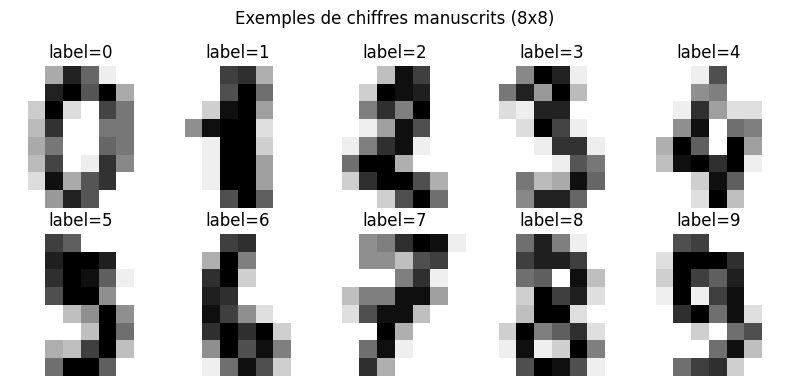

In [2]:
# Chargement des chiffres manuscrits
digits = load_digits()
X = digits.data       # 1797 images x 64 pixels (vecteurs aplanis)
y = digits.target     # etiquettes 0-9 (utilisees UNIQUEMENT pour verification)

print(f"X shape : {X.shape}")                       # attendu (1797, 64)
print(f"Nombre de classes : {len(np.unique(y))}")   # attendu 10

# Apercu de quelques images
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f"label={y[i]}")
    ax.axis('off')
plt.suptitle("Exemples de chiffres manuscrits (8x8)")
plt.tight_layout()
plt.show()

## 2. Clustering avec KMeans

KMeans partitionne les données en `k` clusters. Il procède itérativement : (1) il affecte chaque point au centroïde le plus proche, puis (2) déplace chaque centroïde sur la moyenne de ses points. L'algorithme minimise l'**inertie** (somme des carrés des distances de chaque point à son centroïde). Il faut fournir `k` en entrée — nous utilisons 10 ici (nous savons qu'il y a 10 chiffres), puis nous verrons comment choisir `k` objectivement avec la méthode du coude.

In [3]:
# Clustering KMeans avec 10 clusters
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X)

print(f"Inertie (within-cluster sum of squares) : {kmeans.inertia_:.2f}")
print(f"Labels de cluster (10 premiers points) : {kmeans.labels_[:10]}")
print("Attention : les identifiants de cluster sont ARBITRAIRES "
      "(le cluster 3 ne correspond pas forcement au chiffre 3).")

Inertie (within-cluster sum of squares) : 1165256.30
Labels de cluster (10 premiers points) : [1 3 3 6 9 8 5 4 3 8]
Attention : les identifiants de cluster sont ARBITRAIRES (le cluster 3 ne correspond pas forcement au chiffre 3).


## 3. Choisir k : la méthode du coude

L'inertie **décroît** toujours quand `k` augmente (plus de clusters = des groupes plus serrés). Il n'existe pas de « vrai » `k` déductible de la seule inertie, mais la courbe présente souvent un **coude** (en anglais *elbow*) : un point d'inflexion où ajouter des clusters n'apporte plus guère de gain. Ce coude est un choix raisonnable pour `k`.

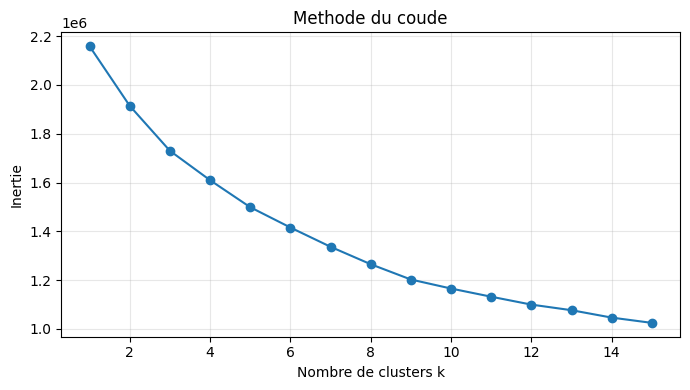

Inertie pour k=10 : 1165256.30
Un coude est visible autour de k=10, coherent avec les 10 chiffres.


In [4]:
# Methode du coude : inertie en fonction du nombre de clusters k
inerties = []
for k in range(1, 16):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inerties.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 16), inerties, 'o-')
plt.xlabel("Nombre de clusters k")
plt.ylabel("Inertie")
plt.title("Methode du coude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Inertie pour k=10 : {inerties[9]:.2f}")
print("Un coude est visible autour de k=10, coherent avec les 10 chiffres.")

### Exercice 1 : la décroissance de l'inertie

**Objectif** : mesurer la chute d'inertie lorsqu'on passe de k=5 à k=10 clusters, à partir de la liste `inerties`.

**Indice** : `inerties` est une liste 0-indexée (indice 0 = k=1, indice 4 = k=5, indice 9 = k=10). La baisse vaut `inerties[4] - inerties[9]`.

In [5]:
# Exercice 1 : chute d'inertie entre k=5 et k=10
# inerties est une liste 0-indexee : indice 4 = k=5, indice 9 = k=10
baisse_inertie = None  # TODO etudiant : remplacer (inerties[4] - inerties[9])
print(f"Exercice 1 a completer : l'inertie baisse de {baisse_inertie} entre k=5 et k=10")

Exercice 1 a completer : l'inertie baisse de None entre k=5 et k=10


## 4. Réduction de dimension : l'ACP (PCA)

Chaque chiffre est un point dans un espace à 64 dimensions — impossible à tracer directement. La PCA (*Principal Component Analysis*, ou ACP en français) identifie les directions de **variance maximale** et projette les données sur les premières. La première composante principale capture le plus de variance, la deuxième le résidu orthogonal, etc. Projeter sur les 2 premières composantes donne un nuage de points 2D que l'on PEUT visualiser — et souvent les classes s'y séparent.

> **Référence.** Pearson, K. (1901), *On Lines and Planes of Closest Fit to Systems of Points in Space*, Philosophical Magazine 2(11):559-572. Article fondateur de l'Analyse en Composantes Principales : la recherche des axes de variance maximale comme projection optimale (au sens des moindres carrés).

Variance expliquee par les 2 premieres composantes : 0.285 (28.5%)


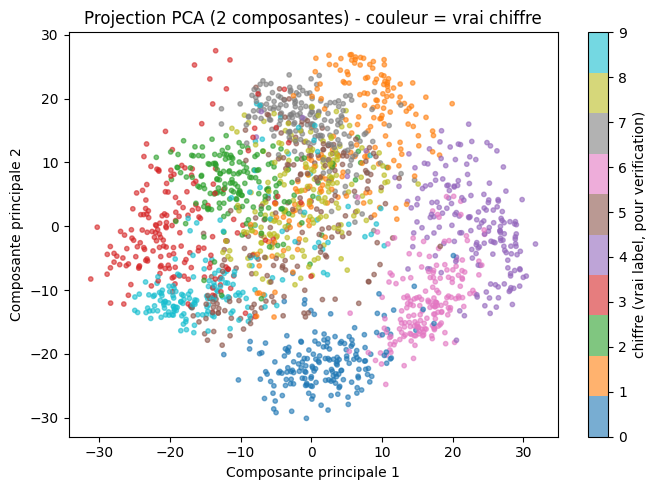

Meme en 2D, les classes de chiffres forment des groupes visibles : la PCA non supervisée retrouve la structure connue.


In [6]:
# Reduction de dimension : PCA a 2 composantes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

variance_2d = pca.explained_variance_ratio_.sum()
print(f"Variance expliquee par les 2 premieres composantes : {variance_2d:.3f} "
      f"({variance_2d*100:.1f}%)")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', s=10, alpha=0.6)
plt.colorbar(label="chiffre (vrai label, pour verification)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Projection PCA (2 composantes) - couleur = vrai chiffre")
plt.tight_layout()
plt.show()
print("Meme en 2D, les classes de chiffres forment des groupes visibles : "
      "la PCA non supervisée retrouve la structure connue.")

### Exercice 2 : combien de composantes garder ?

Les 2 premières composantes ne captent qu'une partie de la variance. Pour compresser sans trop perdre d'information, on cherche le nombre de composantes suffisant à atteindre **95 % de variance cumulée**.

**Étapes**
1. La cellule suivante ajuste une `PCA()` (toutes les composantes) sur `X` et définit `variance_expliquee` (le ratio de variance de chacune des 64 composantes).
2. Calculez la variance cumulée avec `np.cumsum(variance_expliquee)`.
3. Trouvez le premier indice où la cumulée dépasse 0.95 (rappelez-vous d'ajouter 1 pour passer de l'indice au nombre de composantes).

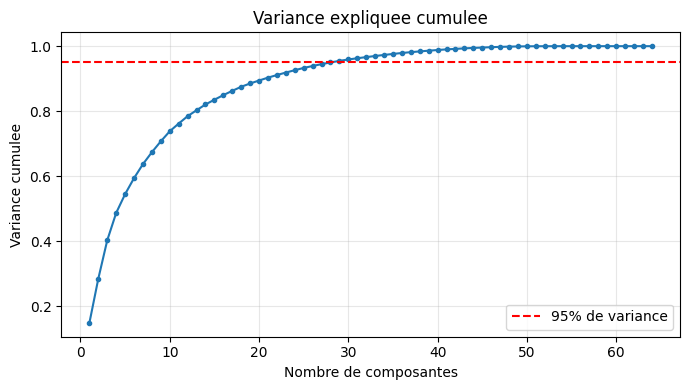

Il faut environ 29 composantes pour atteindre 95% de la variance.


In [7]:
# Variance expliquee par toutes les composantes (64)
pca_full = PCA().fit(X)
variance_expliquee = pca_full.explained_variance_ratio_

cumul = np.cumsum(variance_expliquee)
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumul) + 1), cumul, 'o-', markersize=3)
plt.axhline(0.95, color='r', ls='--', label="95% de variance")
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance cumulee")
plt.title("Variance expliquee cumulee")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_95 = int(np.argmax(cumul >= 0.95) + 1)
print(f"Il faut environ {n_95} composantes pour atteindre 95% de la variance.")

In [8]:
# Exercice 2 : nombre de composantes pour 95% de variance expliquee
# variance_expliquee est le ratio de variance par composante (64 valeurs)
cumul = None  # TODO etudiant : remplacer (np.cumsum(variance_expliquee))
# TODO etudiant : nombre de composantes pour atteindre 95% (premier indice ou cumul >= 0.95)
n_composantes_95 = None  # TODO etudiant : remplacer
print(f"Exercice 2 a completer : {n_composantes_95} composantes suffisent pour 95% de la variance")

Exercice 2 a completer : None composantes suffisent pour 95% de la variance


## 5. Vérifier le clustering contre les vraies étiquettes

KMeans a trouvé 10 clusters **sans voir les étiquettes**. Ces clusters correspondent-ils aux 10 classes de chiffres ? On peut le vérifier avec une matrice de confusion entre `kmeans.labels_` et `y`. **Attention** : les identifiants de cluster étant arbitraires, la matrice est une permutation des colonnes — mais si une structure diagonale se dessine, la méthode non supervisée a bien retrouvé les classes. C'est la démonstration honnête que l'apprentissage non supervisé redécouvre une structure connue.

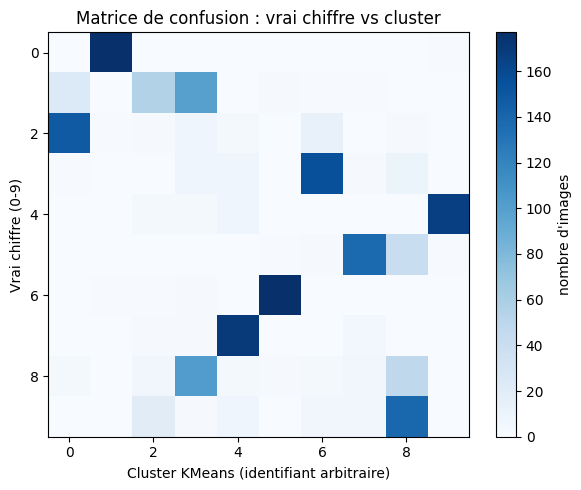

Chaque ligne = un vrai chiffre, chaque colonne = un cluster.
Une structure diagonale (a permutation des colonnes pres) signifie
que les clusters correspondent aux classes de chiffres.


In [9]:
# Verification : matrice de confusion entre vrais chiffres et clusters KMeans
matrice = confusion_matrix(y, kmeans.labels_)

plt.figure(figsize=(6, 5))
plt.imshow(matrice, cmap='Blues', aspect='auto')
plt.colorbar(label="nombre d'images")
plt.xlabel("Cluster KMeans (identifiant arbitraire)")
plt.ylabel("Vrai chiffre (0-9)")
plt.title("Matrice de confusion : vrai chiffre vs cluster")
plt.tight_layout()
plt.show()

print("Chaque ligne = un vrai chiffre, chaque colonne = un cluster.")
print("Une structure diagonale (a permutation des colonnes pres) signifie")
print("que les clusters correspondent aux classes de chiffres.")

### Exercice 3 : les clusters correspondent-ils aux chiffres ?

**Objectif** : pour le vrai chiffre « 0 » (les points où `y == 0`), trouver quel cluster (0 à 9) est le plus fréquent parmi ceux attribués par KMeans.

**Étapes**
1. Construisez le masque `masque_zero = (y == 0)`.
2. Sélectionnez les clusters de ces points : `clusters_zero = kmeans.labels_[masque_zero]`.
3. Trouvez le cluster dominant avec `np.bincount(clusters_zero).argmax()`.

In [10]:
# Exercice 3 : pour le vrai chiffre 0, quel cluster (0-9) est le plus frequent ?
masque_zero = (y == 0)                        # les points dont le vrai chiffre est 0
clusters_zero = kmeans.labels_[masque_zero]   # leurs clusters assignes par KMeans
# TODO etudiant : trouver le cluster le plus frequent parmi clusters_zero
cluster_dominant_zero = None  # TODO etudiant : remplacer (np.bincount(clusters_zero).argmax())
print(f"Exercice 3 a completer : le chiffre 0 tombe surtout dans le cluster {cluster_dominant_zero}")

Exercice 3 a completer : le chiffre 0 tombe surtout dans le cluster None


## 6. Reconstruire une image à partir de la PCA

La PCA est aussi une **compression** : projeter sur `k` composantes puis *inverse-transformer* reconstruit une approximation de l'original. Moins de composantes = plus de compression et plus de flou. Cette section illustre visuellement le compromis entre réduction de dimension et perte d'information.

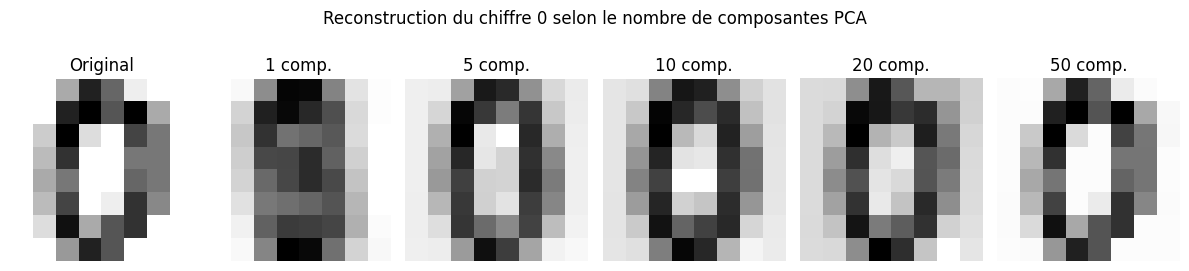

Plus on garde de composantes, plus l'image reconstruite devient nette.


In [11]:
# Reconstruction d'un chiffre a partir d'un nombre croissant de composantes PCA
image_originale = digits.images[0]
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
axes[0].imshow(image_originale, cmap='gray_r')
axes[0].set_title("Original")
axes[0].axis('off')

for i, n in enumerate([1, 5, 10, 20, 50]):
    p = PCA(n_components=n)
    proj = p.fit_transform(X)
    recon = p.inverse_transform(proj)
    axes[i + 1].imshow(recon[0].reshape(8, 8), cmap='gray_r')
    axes[i + 1].set_title(f"{n} comp.")
    axes[i + 1].axis('off')
plt.suptitle("Reconstruction du chiffre 0 selon le nombre de composantes PCA")
plt.tight_layout()
plt.show()
print("Plus on garde de composantes, plus l'image reconstruite devient nette.")

## 7. Synthèse : supervisé vs non supervisé

Le **supervisé** (notebooks 2.1 à 2.5) dispose d'étiquettes et apprend à **prédire**. Le **non supervisé** (ce notebook) n'a pas d'étiquettes et **trouve** de la structure (clusters) ou **compresse** (PCA). En pratique, ces approches se combinent souvent : on peut appliquer une PCA avant un clustering, ou avant un modèle supervisé pour accélérer l'apprentissage et réduire le surajustement.

> **Référence.** Hastie, T., Tibshirani, R. & Friedman, J. (2009), *The Elements of Statistical Learning*, Springer (2e éd.), §14.3. — Synthèse du clustering et de la réduction de dimension dans le cadre de l'apprentissage statistique.

## Conclusion : fin du socle ML

Vous avez parcouru toute la série `02-ML-Cours` : (2.1) le workflow ML, (2.2) la descente de gradient, (2.3) la régression linéaire et logistique, (2.4) les arbres / forêts / ensembles, (2.5) le compromis biais-variance / validation croisée / courbes ROC, et enfin (2.6) le clustering et la PCA. Un étudiant ayant travaillé les six notebooks dispose désormais du **socle ML canonique** qui manquait entre NumPy/Pandas et les ateliers agents. Ceci conclut la série `02-ML-Cours`.

## References

1. MacQueen, J. (1967). *Some Methods for Classification and Analysis of Multivariate Observations*. Proceedings of the Fifth Berkeley Symposium on Mathematical Statistics and Probability 1:281-297. — La méthode des k-moyennes, partitionnement par minimisation de l'inertie intra-cluster.
2. Pearson, K. (1901). *On Lines and Planes of Closest Fit to Systems of Points in Space*. Philosophical Magazine 2(11):559-572. — Article fondateur de l'Analyse en Composantes Principales (axes de variance maximale).
3. Jolliffe, I.T. (2002). *Principal Component Analysis*. Springer (2e éd.). — Référence sur l'ACP : variance expliquée, choix du nombre de composantes.
4. Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer (2e éd.), §14.3. — Clustering et réduction de dimension.
5. Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research 12:2825-2830. — `KMeans`, `PCA`, `load_digits`.